In [ ]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [153]:
ideal = cv2.imread("ideal.jpg")
sample = cv2.imread("sample3.jpg")

print(ideal.shape)
print(sample.shape)

#plt.imshow(cv2.cvtColor(ideal, cv2.COLOR_BGR2RGB))
#plt.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))

(600, 600, 3)
(600, 600, 3)


Text(0.5, 1.0, 'Sample Gear (Grayscale)')

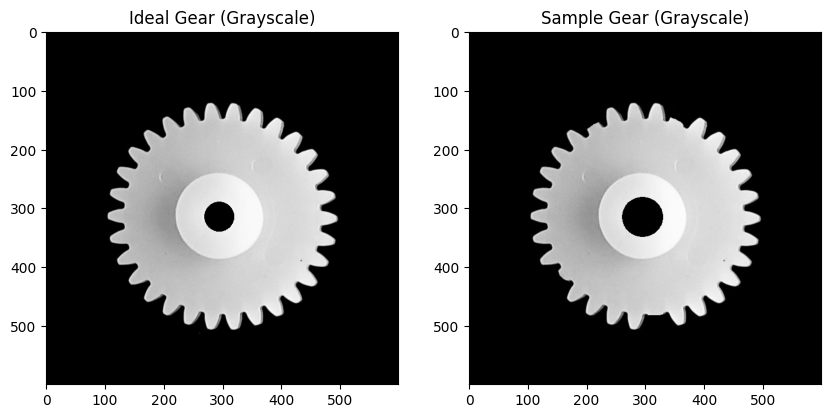

In [154]:
ideal_g = cv2.cvtColor(ideal, cv2.COLOR_BGR2GRAY)
sample_g = cv2.cvtColor(sample, cv2.COLOR_BGR2GRAY)

fig, axs = plt.subplots(1, 2, figsize=(10, 10))
axs[0].imshow(ideal_g, cmap='gray')
axs[0].set_title('Ideal Gear (Grayscale)')
axs[1].imshow(sample_g, cmap='gray')
axs[1].set_title('Sample Gear (Grayscale)')

Text(0.5, 1.0, 'Thresholded Sample Gear (Grayscale)')

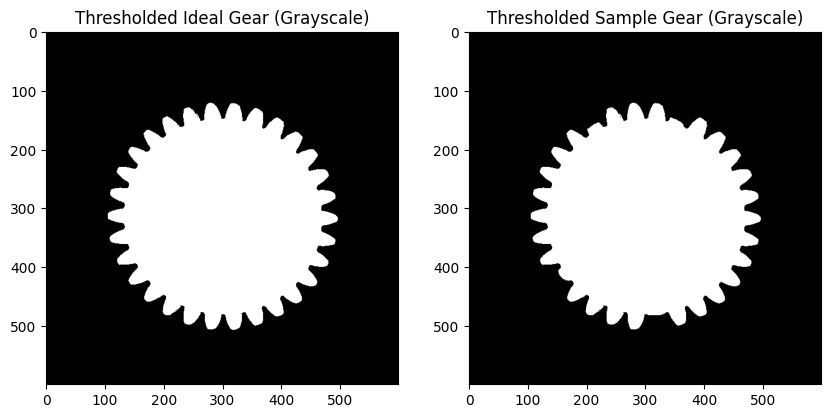

In [155]:
thresh_v_i, thresh_ideal = cv2.threshold(ideal_g, 90, 255, cv2.THRESH_BINARY)
thresh_v_s, thresh_sample = cv2.threshold(sample_g, 90, 255, cv2.THRESH_BINARY)

diff_w_d= cv2.bitwise_xor(thresh_ideal, thresh_sample)
diff_w_d = cv2.medianBlur(diff_w_d, 5)
contours_w_d,_ = cv2.findContours(diff_w_d, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

mask = np.zeros_like(ideal_g)
center = (ideal_g.shape[1]//2, ideal_g.shape[0]//2)
radius = 100
cv2.circle(mask, center, radius, 255, -1)

thresh_ideal = cv2.bitwise_or(thresh_ideal, mask)
thresh_sample = cv2.bitwise_or(thresh_sample, mask)

fig, axs = plt.subplots(1, 2, figsize=(10, 10))
axs[0].imshow(thresh_ideal, cmap='gray')
axs[0].set_title('Thresholded Ideal Gear (Grayscale)')
axs[1].imshow(thresh_sample, cmap='gray')
axs[1].set_title('Thresholded Sample Gear (Grayscale)')

Text(0.5, 1.0, 'Difference between ideal and sample gears')

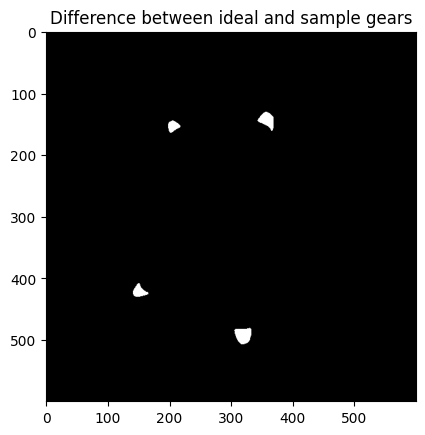

In [156]:
diff = cv2.bitwise_xor(thresh_ideal, thresh_sample)
diff = cv2.bitwise_xor(thresh_ideal, thresh_sample)
diff = cv2.medianBlur(diff, 5)

plt.imshow(diff, cmap='gray')
plt.title('Difference between ideal and sample gears')

In [157]:
contours,_ = cv2.findContours(diff, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
print(f"Number of defected teeth is {len(contours)}")
 
if (diff_w_d > diff).any():
    print("Diameter is different")
else:
        print("Diameter is the same")



Number of defected teeth is 4
Diameter is different
